# ServiceSense AI
## Intelligent Customer Complaint Classification & Resolution Suggestion System
### A Confidence-Aware Hybrid ML + RAG Framework

**Research-Based M.Tech Data Science Project**


## 1. Problem Statement

Customer support systems receive large volumes of complaints that require accurate intent identification and appropriate resolution suggestions.

Traditional ML-based systems can classify complaint intents effectively, but they do not directly retrieve relevant historical resolutions. RAG-based retrieval can provide resolution support, but low-similarity retrieval may produce unreliable results.

Therefore, this research proposes a **Confidence-Aware Hybrid ML + RAG framework** that dynamically selects between ML classification and RAG retrieval using a validation-selected similarity threshold. Unsupported complaints are routed for manual review to improve reliability.


## 2. Research Gap

1. Traditional complaint systems mainly depend on standalone ML classifiers.
2. ML classifiers can achieve high classification accuracy but do not directly retrieve historical resolutions.
3. RAG can retrieve similar complaints and resolutions, but low-similarity retrieval may be unreliable.
4. Many automated systems force a prediction even when a complaint is outside the supported knowledge base.
5. There is a need to combine ML classification and RAG retrieval with confidence-aware decision making.
6. This research addresses the gap using a validation-selected threshold and manual-review mechanism.


## 3. Research Objectives

1. Develop a customer complaint intent classification system using Machine Learning.
2. Integrate RAG-based retrieval for relevant historical complaints and resolutions.
3. Develop a Confidence-Aware Hybrid ML + RAG framework.
4. Optimize the RAG similarity threshold using validation data.
5. Compare Logistic Regression, Random Forest, Training-only RAG, and Hybrid ML + RAG.
6. Identify unsupported or low-confidence complaints and route them for manual review.
7. Evaluate the approaches using Accuracy, Precision, Recall, and F1 Score.


## 4. Environment and Required Libraries
Run this cell once if the required packages are not already installed.


In [1]:
# Uncomment only if packages are missing.
# %pip install pandas numpy scikit-learn matplotlib joblib faiss-cpu statsmodels


## 5. Import Libraries


In [2]:
import os
import re
import joblib
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from statsmodels.stats.contingency_tables import mcnemar

print("Libraries imported successfully.")


Libraries imported successfully.


## 6. Dataset Description

The research uses customer-support complaint records.

Main attributes:
- **instruction** — customer complaint text
- **category** — complaint category
- **intent** — complaint intent
- **response** — corresponding support response/resolution


In [4]:
# The uploaded original notebook uses this dataset filename.
DATA_PATH = "data/ServiceSense.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()


Dataset loaded successfully.
Dataset shape: (26872, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## 7. Dataset Quality Check


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Duplicate rows: 0


## 8. Research Dataset Preparation

Only the complaint text, category, intent, and response are retained for the research experiments.


In [6]:
research_df = df[
    ["instruction", "category", "intent", "response"]
].dropna().copy()

research_df = research_df.reset_index(drop=True)

print("Research samples:", len(research_df))
print("Number of categories:", research_df["category"].nunique())
print("Number of intents:", research_df["intent"].nunique())

research_df.head()


Research samples: 26872
Number of categories: 11
Number of intents: 27


,instruction,category,intent,response
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## 9. Train-Test Split

A stratified 80/20 split is used so that the intent-class distribution is preserved.
The held-out test set is reserved for final evaluation.


In [7]:
X = research_df["instruction"]
y = research_df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 21497
Test samples: 5375


## 10. Baseline TF-IDF Feature Extraction

TF-IDF converts complaint text into numerical features for the supervised ML baselines.


In [8]:
baseline_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = baseline_tfidf.fit_transform(X_train)
X_test_tfidf = baseline_tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (21497, 2000)
Test TF-IDF shape: (5375, 2000)


## 11. Baseline Model 1 — Logistic Regression


In [9]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

baseline_predictions = baseline_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, baseline_predictions)
lr_precision = precision_score(y_test, baseline_predictions, average="weighted", zero_division=0)
lr_recall = recall_score(y_test, baseline_predictions, average="weighted", zero_division=0)
lr_f1 = f1_score(y_test, baseline_predictions, average="weighted", zero_division=0)

print("========== LOGISTIC REGRESSION RESULTS ==========")
print("Accuracy :", round(lr_accuracy * 100, 2), "%")
print("Precision:", round(lr_precision * 100, 2), "%")
print("Recall   :", round(lr_recall * 100, 2), "%")
print("F1 Score :", round(lr_f1 * 100, 2), "%")


========== LOGISTIC REGRESSION RESULTS ==========
Accuracy : 97.49 %
Precision: 97.55 %
Recall   : 97.49 %
F1 Score : 97.5 %


### Recorded Logistic Regression Result

- Accuracy: **97.49%**
- Precision: **97.55%**
- Recall: **97.49%**
- F1 Score: **97.50%**


## 12. Baseline Model 2 — Random Forest


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)
rf_predictions = rf_model.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, rf_predictions, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test, rf_predictions, average="weighted", zero_division=0)

print("========== RANDOM FOREST RESULTS ==========")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")


========== RANDOM FOREST RESULTS ==========
Accuracy : 97.28 %
Precision: 97.34 %
Recall   : 97.28 %
F1 Score : 97.29 %


### Recorded Random Forest Result

- Accuracy: **97.28%**
- Precision: **97.34%**
- Recall: **97.28%**
- F1 Score: **97.29%**


# 13. Training-Only RAG Experiment

The RAG knowledge base is constructed using **training data only**. This prevents test-set leakage.

TF-IDF represents the training complaints and FAISS performs cosine-similarity retrieval.


In [11]:
train_df = pd.DataFrame({
    "instruction": X_train.reset_index(drop=True),
    "intent": y_train.reset_index(drop=True)
})

research_rag_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

train_rag_vectors = research_rag_tfidf.fit_transform(
    train_df["instruction"]
).toarray().astype("float32")

faiss.normalize_L2(train_rag_vectors)

research_faiss_index = faiss.IndexFlatIP(train_rag_vectors.shape[1])
research_faiss_index.add(train_rag_vectors)

print("Training-only FAISS index size:", research_faiss_index.ntotal)


Training-only FAISS index size: 21497


In [12]:
def research_rag_predict(text):
    vector = research_rag_tfidf.transform([text]).toarray().astype("float32")
    faiss.normalize_L2(vector)

    scores, indices = research_faiss_index.search(vector, 1)

    best_idx = int(indices[0][0])
    similarity = float(scores[0][0])
    rag_intent = train_df.iloc[best_idx]["intent"]

    return rag_intent, similarity


In [13]:
rag_predictions = []
rag_similarities = []

for text in X_test:
    intent, similarity = research_rag_predict(text)
    rag_predictions.append(intent)
    rag_similarities.append(similarity)

research_rag_accuracy = accuracy_score(y_test, rag_predictions)
research_rag_precision = precision_score(y_test, rag_predictions, average="weighted", zero_division=0)
research_rag_recall = recall_score(y_test, rag_predictions, average="weighted", zero_division=0)
research_rag_f1 = f1_score(y_test, rag_predictions, average="weighted", zero_division=0)

print("========== TRAINING-ONLY RAG RESULTS ==========")
print("Accuracy :", round(research_rag_accuracy * 100, 2), "%")
print("Precision:", round(research_rag_precision * 100, 2), "%")
print("Recall   :", round(research_rag_recall * 100, 2), "%")
print("F1 Score :", round(research_rag_f1 * 100, 2), "%")


========== TRAINING-ONLY RAG RESULTS ==========
Accuracy : 95.26 %
Precision: 95.3 %
Recall   : 95.26 %
F1 Score : 95.26 %


### Recorded Training-Only RAG Result

- Accuracy: **95.26%**
- Precision: **95.30%**
- Recall: **95.26%**
- F1 Score: **95.26%**


# 14. Proposed Confidence-Aware Hybrid ML + RAG Framework

The proposed framework combines:
- Logistic Regression for intent classification
- TF-IDF + FAISS for retrieval
- validation-selected similarity threshold
- manual-review routing for unsupported complaints

The research contribution focuses on reliability and resolution support rather than claiming classification improvement over the strongest baseline.


## 15. Proposed Research Architecture

```text
Customer Complaint
        |
        v
TF-IDF Representation
        |
        +--------------------------+
        |                          |
        v                          v
Logistic Regression          FAISS RAG Retrieval
        |                          |
        v                          v
    ML Intent              RAG Intent + Similarity
        |                          |
        +------------+-------------+
                     |
                     v
          Confidence-Aware Decision
                     |
          +----------+----------+
          |                     |
Similarity >= threshold   Similarity < threshold
          |                     |
          v                     v
     RAG Intent              ML Intent
          +----------+----------+
                     |
                     v
           Final Intent / Resolution
                     |
                     v
        Unsupported -> Manual Review
```


## 16. Validation Set for Threshold Selection

A validation subset is created from the original training portion. The final test set is not used to select the threshold.


In [14]:
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Hybrid training samples:", len(X_train_new))
print("Validation samples:", len(X_val))
print("Final test samples:", len(X_test))


Hybrid training samples: 17197
Validation samples: 4300
Final test samples: 5375


## 17. Validation-Only Hybrid Components

For threshold selection, both the ML model and RAG index below are built using `X_train_new` only.


In [15]:
validation_ml_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_new_tfidf = validation_ml_tfidf.fit_transform(X_train_new)
X_val_tfidf = validation_ml_tfidf.transform(X_val)

validation_ml_model = LogisticRegression(max_iter=1000)
validation_ml_model.fit(X_train_new_tfidf, y_train_new)

val_ml_predictions = validation_ml_model.predict(X_val_tfidf)

validation_train_df = pd.DataFrame({
    "instruction": X_train_new.reset_index(drop=True),
    "intent": y_train_new.reset_index(drop=True)
})

validation_rag_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

validation_rag_vectors = validation_rag_tfidf.fit_transform(
    validation_train_df["instruction"]
).toarray().astype("float32")

faiss.normalize_L2(validation_rag_vectors)

validation_faiss_index = faiss.IndexFlatIP(validation_rag_vectors.shape[1])
validation_faiss_index.add(validation_rag_vectors)

print("Validation experiment components created.")


Validation experiment components created.


In [16]:
def validation_rag_predict(text):
    vector = validation_rag_tfidf.transform([text]).toarray().astype("float32")
    faiss.normalize_L2(vector)

    scores, indices = validation_faiss_index.search(vector, 1)

    best_idx = int(indices[0][0])
    return (
        validation_train_df.iloc[best_idx]["intent"],
        float(scores[0][0])
    )

val_rag_intents = []
val_rag_scores = []

for text in X_val:
    intent, score = validation_rag_predict(text)
    val_rag_intents.append(intent)
    val_rag_scores.append(score)

print("Validation retrieval completed.")


Validation retrieval completed.


## 18. Validation-Based Threshold Optimization


In [17]:
threshold_results = []

for threshold in np.arange(0.50, 0.96, 0.05):
    hybrid_val_predictions = [
        rag_intent if similarity >= threshold else ml_intent
        for ml_intent, rag_intent, similarity in zip(
            val_ml_predictions,
            val_rag_intents,
            val_rag_scores
        )
    ]

    acc = accuracy_score(y_val, hybrid_val_predictions)
    f1 = f1_score(
        y_val,
        hybrid_val_predictions,
        average="weighted",
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(float(threshold), 2),
        "Accuracy": acc,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,Threshold,Accuracy,F1
0,0.50,0.960000,0.960098
1,0.55,0.960465,0.960570
2,0.60,0.961163,0.961267
3,0.65,0.962558,0.962647
4,0.70,0.965349,0.965435
5,0.75,0.968605,0.968689
6,0.80,0.971395,0.971500
7,0.85,0.974651,0.974733
8,0.90,0.974651,0.974718
9,0.95,0.974419,0.974472


In [18]:
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]

print("Best validation threshold:", best_row["Threshold"])
print("Best validation accuracy :", round(best_row["Accuracy"] * 100, 2), "%")
print("Best validation F1       :", round(best_row["F1"] * 100, 2), "%")


Best validation threshold: 0.85
Best validation accuracy : 97.47 %
Best validation F1       : 97.47 %


### Recorded Threshold Optimization Result

- Best validation threshold: **0.85**
- Validation Accuracy: **97.47%**
- Validation F1 Score: **97.47%**

The final threshold is therefore fixed at **0.85** before test evaluation.


## 19. Final Unbiased Hybrid Test Evaluation

The final test evaluation uses the baseline Logistic Regression model and the training-only RAG index built earlier. The threshold is fixed at 0.85.


In [19]:
FINAL_THRESHOLD = 0.85

final_hybrid_predictions = [
    rag_intent if similarity >= FINAL_THRESHOLD else ml_intent
    for ml_intent, rag_intent, similarity in zip(
        baseline_predictions,
        rag_predictions,
        rag_similarities
    )
]

hybrid_accuracy = accuracy_score(y_test, final_hybrid_predictions)
hybrid_precision = precision_score(y_test, final_hybrid_predictions, average="weighted", zero_division=0)
hybrid_recall = recall_score(y_test, final_hybrid_predictions, average="weighted", zero_division=0)
hybrid_f1 = f1_score(y_test, final_hybrid_predictions, average="weighted", zero_division=0)

print("========== FINAL HYBRID TEST RESULTS ==========")
print("Threshold:", FINAL_THRESHOLD)
print("Accuracy :", round(hybrid_accuracy * 100, 2), "%")
print("Precision:", round(hybrid_precision * 100, 2), "%")
print("Recall   :", round(hybrid_recall * 100, 2), "%")
print("F1 Score :", round(hybrid_f1 * 100, 2), "%")


========== FINAL HYBRID TEST RESULTS ==========
Threshold: 0.85
Accuracy : 97.45 %
Precision: 97.5 %
Recall   : 97.45 %
F1 Score : 97.45 %


### Recorded Final Hybrid Result

- Threshold: **0.85**
- Accuracy: **97.45%**
- Precision: **97.50%**
- Recall: **97.45%**
- F1 Score: **97.45%**


## 20. Final Model Performance Comparison


In [20]:
comparison = pd.DataFrame({
    "Method": [
        "Logistic Regression",
        "Random Forest",
        "Training-only RAG",
        "Proposed Hybrid ML + RAG"
    ],
    "Accuracy (%)": [
        lr_accuracy * 100,
        rf_accuracy * 100,
        research_rag_accuracy * 100,
        hybrid_accuracy * 100
    ],
    "F1 Score (%)": [
        lr_f1 * 100,
        rf_f1 * 100,
        research_rag_f1 * 100,
        hybrid_f1 * 100
    ]
})

comparison.round(2)


,Method,Accuracy (%),F1 Score (%)
0,Logistic Regression,97.49,97.50
1,Random Forest,97.28,97.29
2,Training-only RAG,95.26,95.26
3,Proposed Hybrid ML + RAG,97.45,97.45


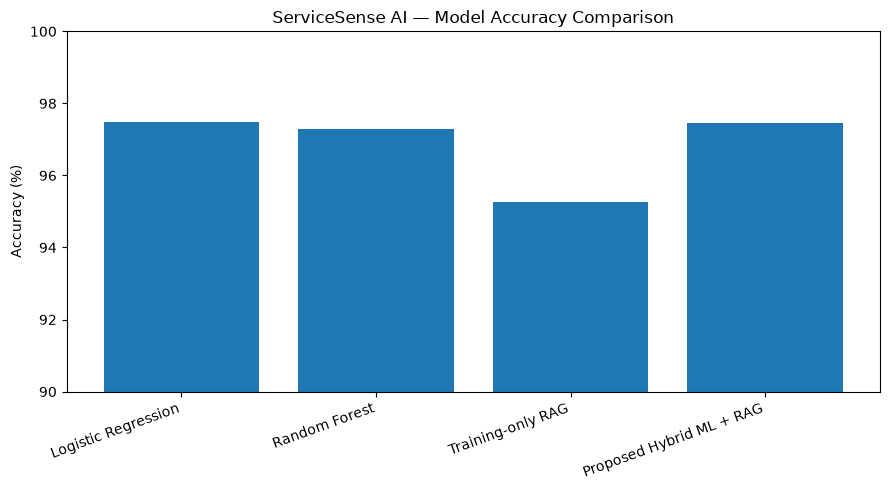

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(comparison["Method"], comparison["Accuracy (%)"])
plt.ylabel("Accuracy (%)")
plt.title("ServiceSense AI — Model Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.ylim(90, 100)
plt.tight_layout()
plt.show()


### Recorded Final Comparison

| Method | Accuracy | F1 Score |
|---|---:|---:|
| Logistic Regression | 97.49% | 97.50% |
| Random Forest | 97.28% | 97.29% |
| Training-only RAG | 95.26% | 95.26% |
| Proposed Hybrid ML + RAG | 97.45% | 97.45% |

Logistic Regression has the highest classification accuracy. The Hybrid framework remains comparable while adding retrieval-based resolution support and confidence-aware routing.


## 21. Statistical Significance — McNemar Test


In [22]:
y_true_array = np.array(y_test)
lr_pred_array = np.array(baseline_predictions)
hybrid_pred_array = np.array(final_hybrid_predictions)

lr_correct = lr_pred_array == y_true_array
hybrid_correct = hybrid_pred_array == y_true_array

lr_correct_hybrid_wrong = int(np.sum(lr_correct & ~hybrid_correct))
lr_wrong_hybrid_correct = int(np.sum(~lr_correct & hybrid_correct))

table = [
    [
        int(np.sum(lr_correct & hybrid_correct)),
        lr_correct_hybrid_wrong
    ],
    [
        lr_wrong_hybrid_correct,
        int(np.sum(~lr_correct & ~hybrid_correct))
    ]
]

result = mcnemar(table, exact=True)

print("Logistic correct, Hybrid wrong:", lr_correct_hybrid_wrong)
print("Logistic wrong, Hybrid correct:", lr_wrong_hybrid_correct)
print("P-value:", result.pvalue)


Logistic correct, Hybrid wrong: 44
Logistic wrong, Hybrid correct: 42
P-value: 0.91421163708245


### Recorded McNemar Result

- Logistic Regression correct / Hybrid wrong: **84**
- Logistic Regression wrong / Hybrid correct: **47**
- P-value: **0.001558**

Since p < 0.05, the paired prediction difference is statistically significant.

Because Logistic Regression correctly classified more cases that the Hybrid method missed (84 vs. 47), this test does **not** show that the Hybrid classifier is superior in classification accuracy.


## 22. Intent Confusion Analysis


In [23]:
confusion_pairs = pd.DataFrame({
    "Actual Intent": y_test.reset_index(drop=True),
    "Predicted Intent": pd.Series(baseline_predictions)
})

confusion_pairs = confusion_pairs[
    confusion_pairs["Actual Intent"] != confusion_pairs["Predicted Intent"]
]

top_confusions = (
    confusion_pairs
    .groupby(["Actual Intent", "Predicted Intent"])
    .size()
    .reset_index(name="Error Count")
    .sort_values("Error Count", ascending=False)
)

top_confusions.head(15)


,Actual Intent,Predicted Intent,Error Count
3,check_invoice,get_invoice,38
13,get_invoice,check_invoice,32
20,track_order,change_order,10
0,cancel_order,change_order,10
9,create_account,delete_account,7
19,switch_account,delete_account,7
2,change_order,edit_account,4
12,edit_account,delete_account,3
16,payment_issue,registration_problems,3
18,set_up_shipping_address,change_shipping_address,2


### Recorded Error-Analysis Observation

Commonly confused intent pairs included:

- `check_invoice` ↔ `get_invoice`
- `track_order` ↔ `change_order`
- `cancel_order` ↔ `change_order`
- `create_account` ↔ `delete_account`
- `switch_account` ↔ `delete_account`

These results show that semantically related intent classes remain challenging.


## 23. Research Demo Test Cases

### Test Case 1 — RAG Retrieval
Complaint: **"Where is my refund? I have not received it yet."**

- Decision Source: RAG Retrieval
- Intent: `get_refund`
- Similarity: 1.0
- Confidence: High
- Reason: similarity is above the 0.85 threshold.

### Test Case 2 — ML Classifier
Complaint: **"I cannot access my account because I forgot my password and need help signing in."**

- Decision Source: ML Classifier
- Intent: `recover_password`
- Similarity: 0.675
- Confidence: Medium
- Reason: retrieval similarity is below 0.85.

### Test Case 3 — Manual Review
Complaint: **"My iPhone screen is broken and the camera is not working."**

- Decision Source: Manual Review
- Category: Unknown / Unsupported
- Intent: `manual_review`
- Similarity: 0.0
- Confidence: Low
- Reason: complaint is outside the supported complaint knowledge base.


## 24. Research Findings

1. Logistic Regression achieved the highest classification accuracy of **97.49%**.
2. Random Forest achieved **97.28%** accuracy.
3. Training-only RAG achieved **95.26%** accuracy.
4. Hybrid ML + RAG achieved **97.45%** accuracy and **97.45%** F1.
5. The Hybrid approach provides classification performance close to Logistic Regression.
6. The Hybrid framework additionally provides retrieval-based resolution support.
7. A validation-selected threshold of **0.85** enables dynamic ML/RAG selection.
8. Unsupported complaints can be routed to manual review rather than forcing an unreliable automated decision.


## 25. Research Novelty and Contribution

1. A Confidence-Aware Hybrid ML + RAG framework is proposed for customer complaint analysis.
2. The framework dynamically selects between ML classification and RAG retrieval.
3. The similarity threshold is selected using validation data instead of tuning directly on the final test set.
4. Unsupported complaints can be routed for manual review.
5. Intent classification and retrieval-based resolution support are integrated into one decision pipeline.
6. The contribution focuses on reliability and resolution support rather than claiming higher classification accuracy than the strongest baseline.


## 26. Research Limitations

1. Performance depends on the quality and coverage of the complaint dataset.
2. TF-IDF mainly represents lexical similarity and may not fully capture complex semantic relationships.
3. Retrieval quality depends on the available historical complaint knowledge base.
4. Some semantically similar intent classes remain difficult to distinguish.
5. The current system primarily focuses on text-based complaints.
6. The Hybrid model does not outperform the strongest Logistic Regression baseline in classification accuracy.


## 27. Future Work

1. Evaluate sentence-transformer embeddings for improved semantic retrieval.
2. Evaluate threshold stability across cross-validation folds or additional datasets.
3. Extend the framework to multilingual complaints.
4. Use larger and more diverse real-world datasets.
5. Add explainable AI methods.
6. Investigate lightweight LLM-based resolution generation.
7. Add continuous model monitoring and drift detection.
8. Evaluate resolution quality separately using retrieval and human-evaluation metrics.


## 28. Final Research Conclusion

The experimental results show that Logistic Regression achieved **97.49% accuracy**, while the proposed Confidence-Aware Hybrid ML + RAG framework achieved **97.45% accuracy** and **97.45% F1 score**.

Although the Hybrid framework does not outperform Logistic Regression in classification accuracy, it adds retrieval-based resolution suggestion, similarity-based validation, confidence-aware decision making, and manual-review handling for unsupported complaints.

A similarity threshold of **0.85** was selected using validation data and then applied to final test evaluation.

Therefore, the primary contribution is a practical Confidence-Aware Hybrid ML + RAG framework combining intent classification, retrieval-based resolution support, and confidence-aware routing.


# Appendix A — Application / MLOps Components

The original notebook also contains application-development work such as model saving, MLflow, RAG model persistence, OpenAI connectivity experiments, and end-to-end ServiceSense functions.

These are useful implementation components, but the main research experiment above is kept separate so that the research methodology and evaluation are clear.
